# Sensitivity tests on [Ce/Mg]-age trends

This notebook re-makes several of the plots in the paper with different selection choices (e.g., higher S/N, lower log(g), or stricter age quality cuts).

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, Normalize
from matplotlib.ticker import MultipleLocator
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from scipy import stats

import paths
from colormaps import paultol
from utils import binned_quantiles, get_bin_centers, import_sample, box_smooth
from plotting import colored_text_legend, truncate_colormap, insert_colorbar_axes
from plotting import ONE_COLUMN_WIDTH, TWO_COLUMN_WIDTH, RADIUS_COLORMAP, AGE_COLORMAP
from global_metallicity_fits import fit_metallicity_bins
from sample import add_kinematics
from residual_abundances import residual_abundances

plt.style.use(paths.styles / 'notebook.mplstyle')

In [111]:
full_sample = import_sample(good_ages=False, cut_limits=True)

## Local abundance trends

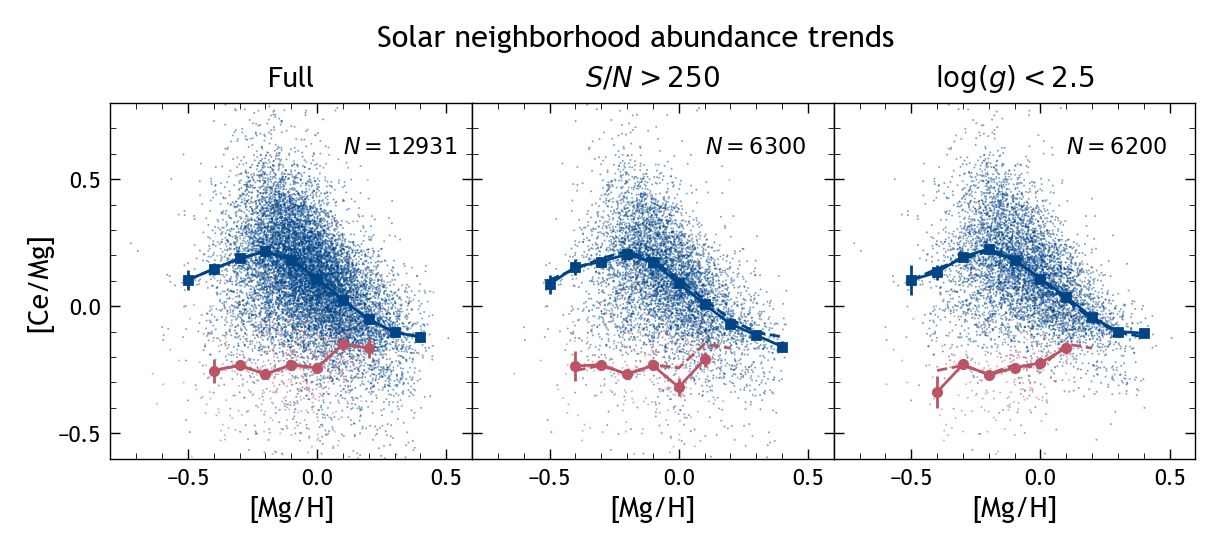

In [112]:
local_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
local_highsn = local_sample[local_sample['snr'] > 250]
local_lowlogg = local_sample[local_sample['logg'] < 2.5]
local_rc = local_sample[(local_sample['logg'] < 2.5) & (local_sample['logg'] > 2.2)]

mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
local_high_ia_medians = binned_quantiles(
    local_sample[local_sample['high_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
local_low_ia_medians = binned_quantiles(
    local_sample[local_sample['low_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

low_ia_color = paultol.highcontrast.colors[2]
high_ia_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 3, 
    figsize=(TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Full', r'$S/N > 250$', r'$\log(g) < 2.5$']
for i, df in enumerate([local_sample, local_highsn, local_lowlogg]):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia['ce_mg_corr'],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia['ce_mg_corr'],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *local_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *local_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.6, 0.8))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Solar neighborhood abundance trends', y=1.05)
plt.show()

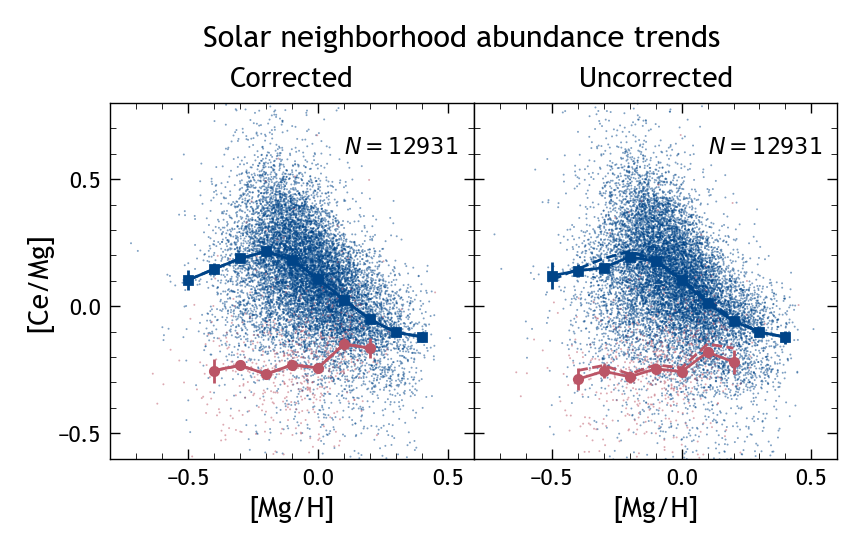

In [113]:
mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
local_high_ia_medians = binned_quantiles(
    local_sample[local_sample['high_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
local_low_ia_medians = binned_quantiles(
    local_sample[local_sample['low_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

low_ia_color = paultol.highcontrast.colors[2]
high_ia_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.67*TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Corrected', 'Uncorrected']
df = local_sample
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia[col],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia[col],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *local_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *local_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.6, 0.8))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Solar neighborhood abundance trends', y=1.05)
plt.show()

## Inner galaxy abundance trends

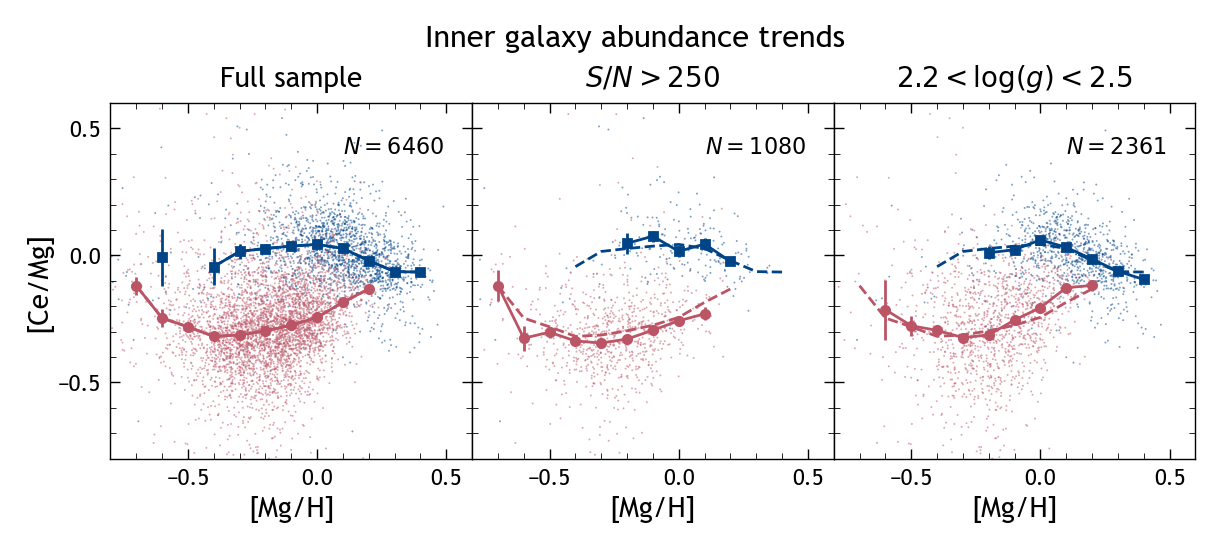

In [114]:
inner_sample = full_sample[(full_sample['Rg'] >= 3) & (full_sample['Rg'] < 5) & (full_sample['z_max'] < 2)]
inner_highsn = inner_sample[inner_sample['snr'] > 250]
inner_lowlogg = inner_sample[inner_sample['logg'] < 2.5]
inner_rc = inner_sample[(inner_sample['logg'] < 2.5) & (inner_sample['logg'] > 2.2)]

mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
inner_high_ia_medians = binned_quantiles(
    inner_sample[inner_sample['high_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
inner_low_ia_medians = binned_quantiles(
    inner_sample[inner_sample['low_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

low_ia_color = paultol.highcontrast.colors[2]
high_ia_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 3, 
    figsize=(TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Full sample', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$']
for i, df in enumerate([inner_sample, inner_highsn, inner_rc]):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia['ce_mg_corr'],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia['ce_mg_corr'],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *inner_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *inner_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.4, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.8, 0.6))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Inner galaxy abundance trends', y=1.05)
plt.show()

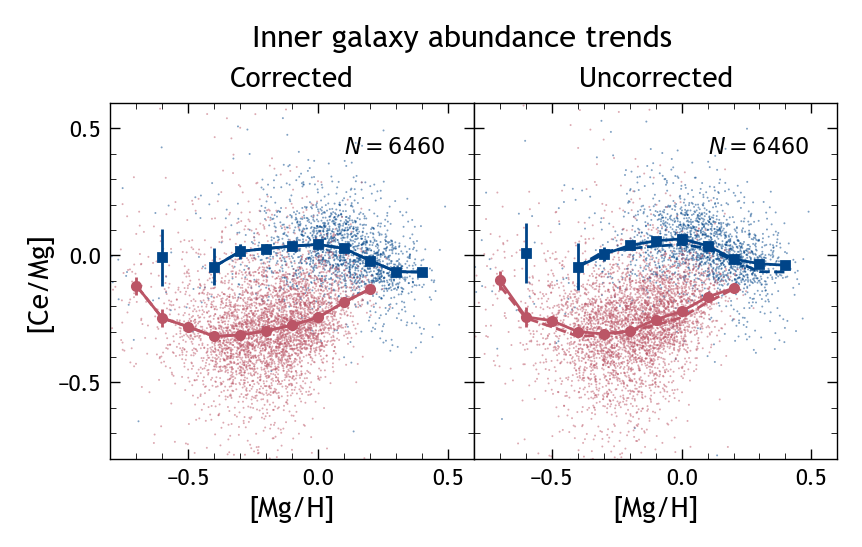

In [115]:
fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.67*TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Corrected', 'Uncorrected']
df = inner_sample
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia[col],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia[col],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *inner_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *inner_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.4, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.8, 0.6))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Inner galaxy abundance trends', y=1.05)
plt.show()

## Local metallicity dependence

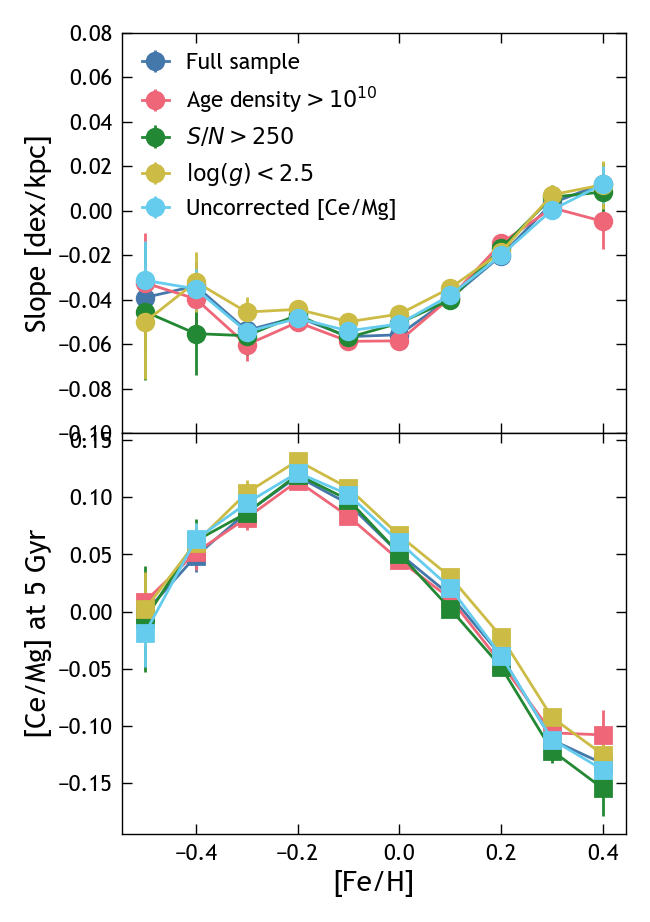

In [203]:
local_ages = local_sample[(local_sample['good_age'])]
local_betterage = local_ages[local_ages['training_density'] > 1e10]
local_highsn_age = local_ages[local_ages['snr'] > 250]
local_lowlogg_age = local_ages[local_ages['logg'] < 2.5]
local_rc_age = local_ages[(local_ages['logg'] < 2.5) & (local_ages['logg'] > 2.2)]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', paultol.bright.colors)
fig, axs = plt.subplots(
    2, 
    figsize=(ONE_COLUMN_WIDTH, 1.6*ONE_COLUMN_WIDTH), 
    sharex=True,
    gridspec_kw={'hspace': 0}
)

met_bins = np.arange(-0.55, 0.46, 0.1)
age_fit_range = (1, 8)
met_col = 'fe_h'
age_delta = 5 # Gyr

ycols = ['ce_mg_corr'] * 4 + ['ce_mg']
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$\log(g) < 2.5$', 'Uncorrected [Ce/Mg]']
for i, df in enumerate([local_ages, local_betterage, local_highsn_age, local_lowlogg_age, local_sample]):
    df_high_ia = df[df['high_ia']]
    # Bin by metallicity and fit linear trend to stars within good age range
    params, errors, met_bin_centers = fit_metallicity_bins(
        df_high_ia, met_bins,
    )
    # Plot slopes
    slopes = params[:,1]
    slope_errs = errors[:,1]
    met_bin_centers = get_bin_centers(met_bins)
    axs[0].errorbar(
        met_bin_centers, slopes, yerr=slope_errs, 
        label=labels[i],
        marker='o', linestyle='-', capsize=0
    )
    # Plot intercepts
    intercepts = params[:,0]
    intercept_errs = errors[:,0]
    axs[1].errorbar(
        met_bin_centers, intercepts, yerr=intercept_errs, 
        label=labels[i],
        marker='s', linestyle='-', capsize=0
    )

axs[0].legend()
axs[1].set_xlabel('[Fe/H]')
axs[0].set_ylabel('Slope [dex/kpc]')
axs[1].set_ylabel('[Ce/Mg] at %s Gyr' % age_delta)
axs[0].set_ylim((-0.1, 0.08))
plt.show()

## Global age trends

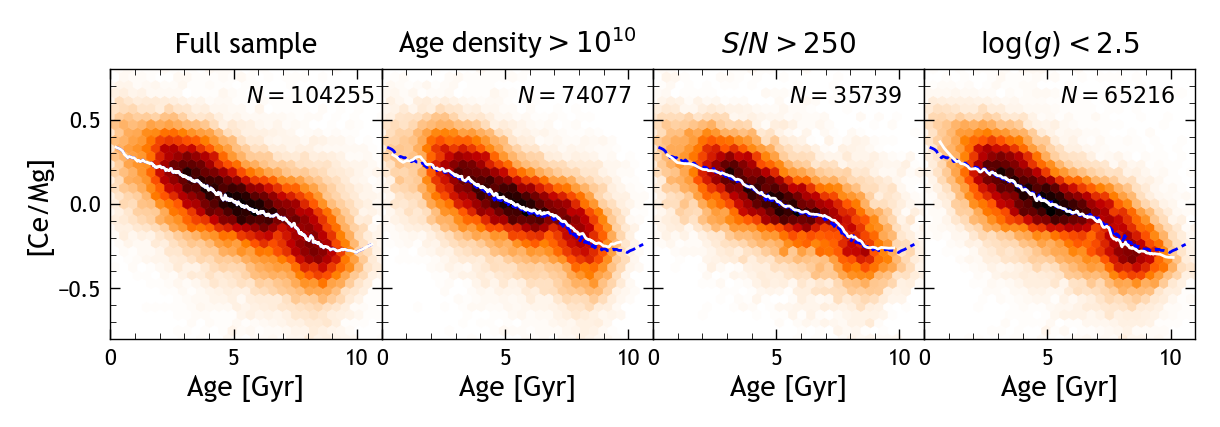

In [117]:
full_ages = full_sample[full_sample['good_age']]
better_ages = full_ages[full_ages['training_density'] > 1e10]
highsn_ages = full_ages[full_ages['snr'] > 250]
lowlogg_ages = full_ages[full_ages['logg'] < 2.5]
rc_ages = full_ages[(full_ages['logg'] < 2.5) & (full_ages['logg'] > 2.2)]

# Compute full sample rolling median trend
full_sorted_ages = full_ages.sort_values('age')[['age', 'ce_mg_corr']]
full_rolling_medians = full_sorted_ages.rolling(
    1000, min_periods=1000, step=250, on='age', center=True
).median()

fig, axs = plt.subplots(
    1, 4, 
    figsize=(TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.8, 0.8)
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$\log(g) < 2.5$']
for i, df in enumerate([full_ages, better_ages, highsn_ages, lowlogg_ages]):
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg_corr'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        cmap='gist_heat_r',
        gridsize=30,
        linewidths=0.2,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        vmin=0
    )
    # Full sample rolling median for comparison
    axs[i].plot(full_rolling_medians['age'], full_rolling_medians['ce_mg_corr'], 'b--')
    # Rolling median
    sorted_ages = df.sort_values('age')[['age', 'ce_mg_corr']]
    rolling_medians = sorted_ages.rolling(
        1000, min_periods=1000, step=250, on='age', center=True
    ).median()
    axs[i].plot(rolling_medians['age'], rolling_medians['ce_mg_corr'], 'w-')
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
plt.show()

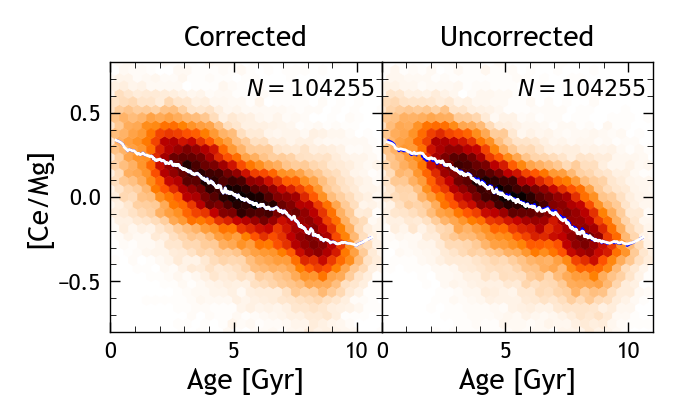

In [118]:
fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.5*TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.8, 0.8)
labels = ['Corrected', 'Uncorrected']
df = full_ages
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    pcm = axs[i].hexbin(
        df['age'], df[col],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        cmap='gist_heat_r',
        gridsize=30,
        linewidths=0.2,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        vmin=0
    )
    # Full sample rolling median for comparison
    axs[i].plot(full_rolling_medians['age'], full_rolling_medians['ce_mg_corr'], 'b--')
    # Rolling median
    sorted_ages = df.sort_values('age')[['age', col]]
    rolling_medians = sorted_ages.rolling(
        1000, min_periods=1000, step=250, on='age', center=True
    ).median()
    axs[i].plot(rolling_medians['age'], rolling_medians[col], 'w-')
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
plt.show()

## Global radial dependence

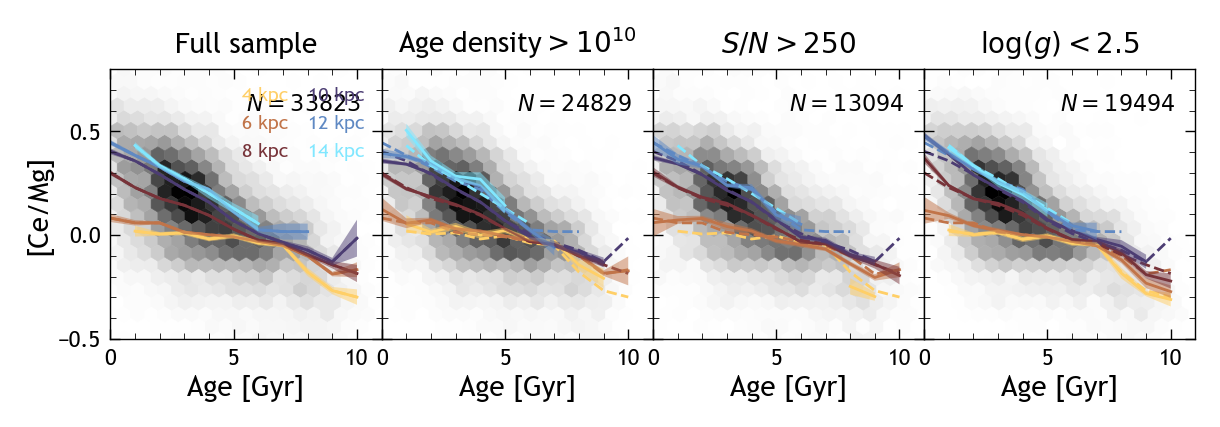

In [145]:
lowz_ages = full_sample[(full_sample['good_age']) & (full_sample['z_max'] < 0.5)]
better_ages = lowz_ages[lowz_ages['training_density'] > 1e10]
highsn_ages = lowz_ages[lowz_ages['snr'] > 250]
lowlogg_ages = lowz_ages[lowz_ages['logg'] < 2.5]
rc_ages = lowz_ages[(lowz_ages['logg'] < 2.5) & (lowz_ages['logg'] > 2.2)]

radius_bin_edges = np.arange(3, 15.1, 2)
age_bin_edges = np.arange(-0.5, 11.6, 1)
radial_cmap = plt.get_cmap(RADIUS_COLORMAP)
norm = BoundaryNorm(radius_bin_edges, radial_cmap.N)

fig, axs = plt.subplots(
    1, 4, 
    figsize=(TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.5, 0.8)
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$\log(g) < 2.5$']
for i, df in enumerate([lowz_ages, better_ages, highsn_ages, lowlogg_ages]):
    # Plot all stars
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg_corr'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        gridsize=20,
        cmap='binary',
        linewidths=0.2,
        mincnt=0,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]]
    )
    # Plot median age trends binned by radius
    for j in range(len(radius_bin_edges)-1):
        radius_bin = radius_bin_edges[j:j+2]
        mean_radius = np.mean(radius_bin)
        df_subset = df[
            (df['Rg'] >= radius_bin[0]) &
            (df['Rg'] < radius_bin[1])
        ]
        age_medians = binned_quantiles(
            df_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *age_medians[:-1], '-', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
            label=f'{int(mean_radius)} kpc'
        )
        axs[i].fill_between(
            age_medians[0],
            age_medians[1]+age_medians[2],
            age_medians[1]-age_medians[2],
            color=radial_cmap(norm(mean_radius)),
            alpha=0.5, edgecolor='none', zorder=2
        )
        # Compare vs median trends in full sample
        full_subset = lowz_ages[
            (lowz_ages['Rg'] >= radius_bin[0]) &
            (lowz_ages['Rg'] < radius_bin[1])
        ]
        full_age_medians = binned_quantiles(
            full_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *full_age_medians[:-1], '--', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
        )
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
colored_text_legend(axs[0], ncols=2, fontsize=7, columnspacing=1)
plt.show()

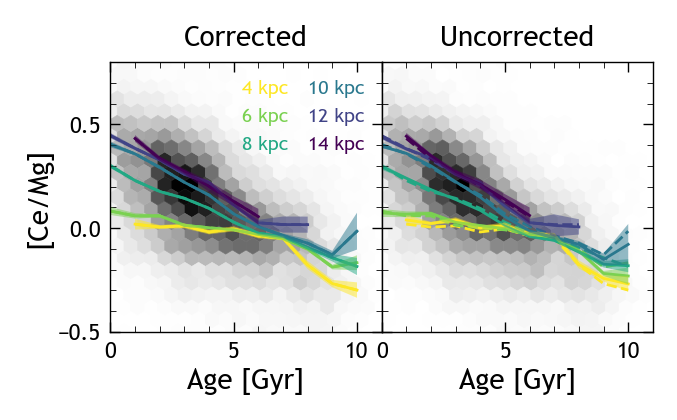

In [120]:
fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.5*TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.5, 0.8)
labels = ['Corrected', 'Uncorrected']
df = lowz_ages
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    # Plot all stars
    pcm = axs[i].hexbin(
        df['age'], df[col],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        gridsize=20,
        cmap='binary',
        linewidths=0.2,
        mincnt=0,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]]
    )
    # Plot median age trends binned by radius
    for j in range(len(radius_bin_edges)-1):
        radius_bin = radius_bin_edges[j:j+2]
        mean_radius = np.mean(radius_bin)
        df_subset = df[
            (df['Rg'] >= radius_bin[0]) &
            (df['Rg'] < radius_bin[1])
        ]
        age_medians = binned_quantiles(
            df_subset, col, 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *age_medians[:-1], '-', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
            label=f'{int(mean_radius)} kpc'
        )
        axs[i].fill_between(
            age_medians[0],
            age_medians[1]+age_medians[2],
            age_medians[1]-age_medians[2],
            color=radial_cmap(norm(mean_radius)),
            alpha=0.5, edgecolor='none', zorder=2
        )
        # Compare vs median trends in full sample
        full_subset = lowz_ages[
            (lowz_ages['Rg'] >= radius_bin[0]) &
            (lowz_ages['Rg'] < radius_bin[1])
        ]
        full_age_medians = binned_quantiles(
            full_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *full_age_medians[:-1], '--', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
        )
    # Sample size
    # axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
colored_text_legend(axs[0], ncols=2, fontsize=7, columnspacing=1)
plt.show()

(31300, 477)


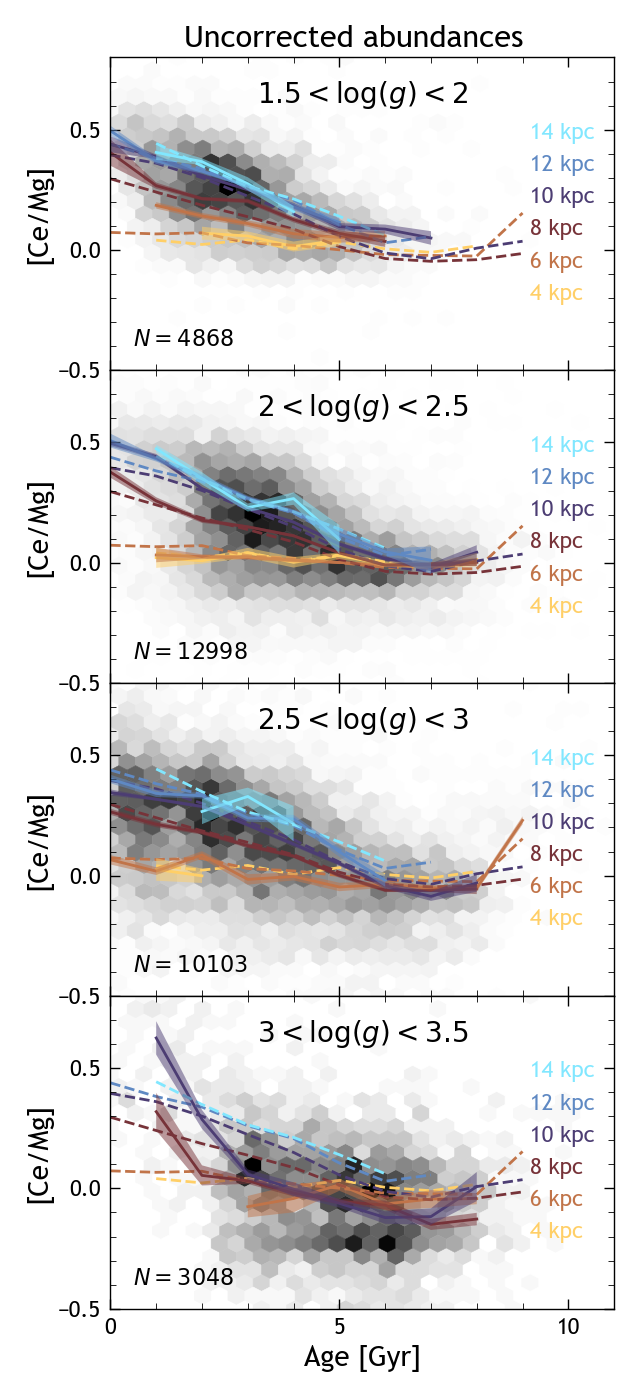

In [202]:
lowz_ages = full_sample[(full_sample['good_age']) & (full_sample['z_max'] < 0.5) & (full_sample['high_ia'])]
print(lowz_ages.shape)
logg_bins = [(1.5, 2), (2, 2.5), (2.5, 3), (3, 3.5)]
radius_bin_edges = np.arange(3, 15.1, 2)
age_bin_edges = np.arange(-0.5, 11.6, 1)
radial_cmap = plt.get_cmap(RADIUS_COLORMAP)
norm = BoundaryNorm(radius_bin_edges, radial_cmap.N)

fig, axs = plt.subplots(
    4, 1, 
    figsize=(ONE_COLUMN_WIDTH, 2.5*ONE_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0, 'hspace': 0}
)
xlim = (0, 11)
ylim = (-0.5, 0.8)
for i, logg_bin in enumerate(logg_bins):
    df = lowz_ages[(lowz_ages['logg'] > logg_bin[0]) & (lowz_ages['logg'] < logg_bin[1])]
    # Plot all stars
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        gridsize=(30, 12),
        cmap='binary',
        linewidths=0.2,
        mincnt=0,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]]
    )
    # Plot median age trends binned by radius
    for j in range(len(radius_bin_edges)-1):
        radius_bin = radius_bin_edges[j:j+2]
        mean_radius = np.mean(radius_bin)
        df_subset = df[
            (df['Rg'] >= radius_bin[0]) &
            (df['Rg'] < radius_bin[1])
        ]
        age_medians = binned_quantiles(
            df_subset, 'ce_mg', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *age_medians[:-1], '-', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
            label=f'{int(mean_radius)} kpc'
        )
        axs[i].fill_between(
            age_medians[0],
            age_medians[1]+age_medians[2],
            age_medians[1]-age_medians[2],
            color=radial_cmap(norm(mean_radius)),
            alpha=0.5, edgecolor='none', zorder=2
        )
        # Compare vs median trends in full sample
        full_subset = lowz_ages[
            (lowz_ages['Rg'] >= radius_bin[0]) &
            (lowz_ages['Rg'] < radius_bin[1])
        ]
        full_age_medians = binned_quantiles(
            full_subset, 'ce_mg', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *full_age_medians[:-1], '--', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
        )
    # Sample size
    axs[i].text(0.5, -0.4, r'$N=%s$' % df.shape[0])
    axs[i].set_title(r'$%s<\log(g)<%s$' % logg_bin, y=0.8)
    handles, labels = axs[i].get_legend_handles_labels()
    colored_text_legend(axs[i], loc='center right', fontsize=8, invert=True)

fig.suptitle('Uncorrected abundances', y=0.9)
axs[-1].set_xlabel('Age [Gyr]')
for ax in axs:
    # ax.set_xlabel('Age [Gyr]')
    ax.set_ylabel('[Ce/Mg]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
# colored_text_legend(axs[0], ncols=1, fontsize=7, columnspacing=1)
plt.savefig(paths.extra / 'logg_trends_test')
plt.show()

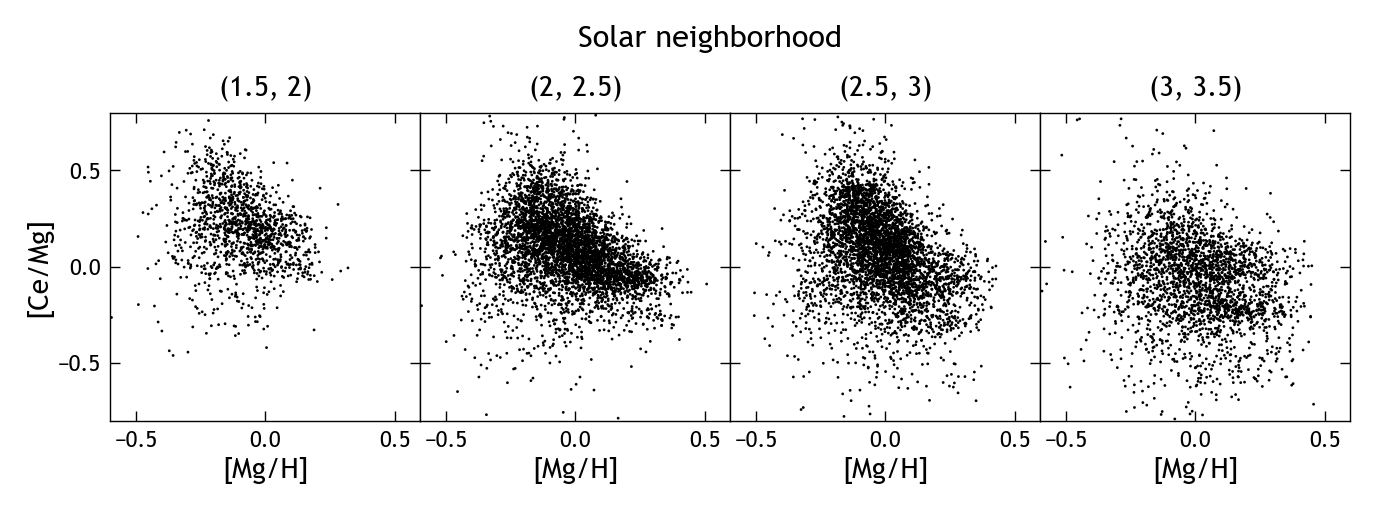

In [193]:
logg_bins = [(1.5, 2), (2, 2.5), (2.5, 3), (3, 3.5)]
# solar_sample = full_sample[(full_sample['r_med_photogeo'] < 1000)]
solar_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
fig, axs = plt.subplots(1, 4, figsize=(8, 2), sharex=True, sharey=True, gridspec_kw={'wspace': 0})
for i, ax in enumerate(axs):
    logg_lim = logg_bins[i]
    subset = solar_sample[(solar_sample['logg'] > logg_lim[0]) & (solar_sample['logg'] < logg_lim[1])]
    ax.scatter(
        subset['mg_h'], subset['ce_mg'], 
        s=1, c='k', rasterized=True, edgecolors='none',
    )
    ax.set_xlabel('[Mg/H]')
    ax.set_title(logg_lim)
axs[0].set_ylabel('[Ce/Mg]')
axs[0].set_xlim((-0.6, 0.6))
axs[0].set_ylim((-0.8, 0.8))
fig.suptitle('Solar neighborhood', y=1.1)
plt.show()

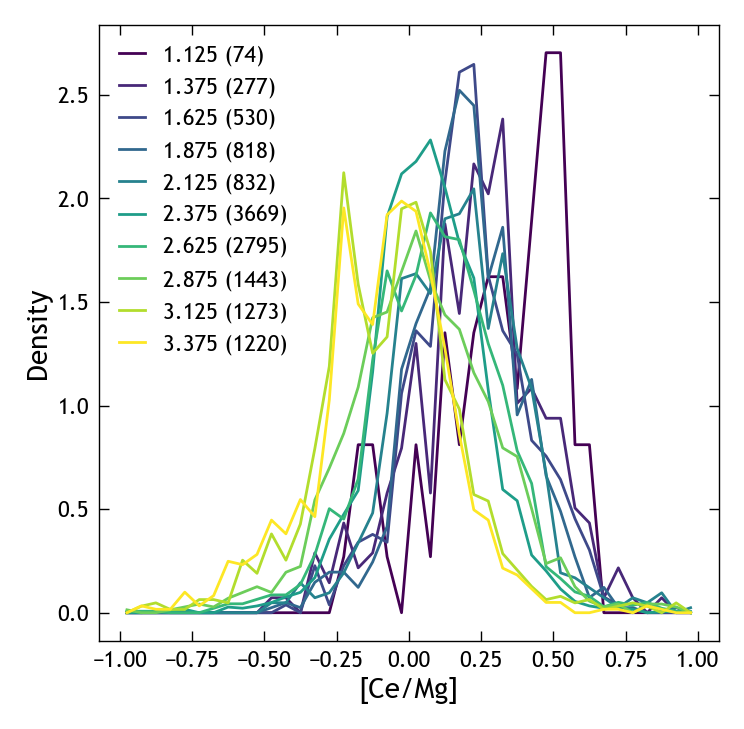

In [122]:
logg_bin_edges = np.arange(1, 3.6, 0.25)
abund_bins = np.arange(-1, 1.02, 0.05)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(logg_bin_edges, radial_cmap.N)
local_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
fig, ax = plt.subplots()
for i in range(len(logg_bin_edges)-1):
    logg_bin = logg_bin_edges[i:i+2]
    mean_logg = np.mean(logg_bin)
    df = local_sample[(local_sample['logg'] > logg_bin[0]) & (local_sample['logg'] < logg_bin[1])]
    hist, bin_edges = np.histogram(df['ce_mg'], bins=abund_bins, density=True)
    # hist_smooth = box_smooth(hist, bin_edges, 0.2)
    ax.plot(get_bin_centers(bin_edges), hist, color=cmap(norm(mean_logg)), label='%s (%s)' % (mean_logg, df.shape[0]))
ax.set_xlabel('[Ce/Mg]')
ax.set_ylabel('Density')
ax.legend()
plt.show()

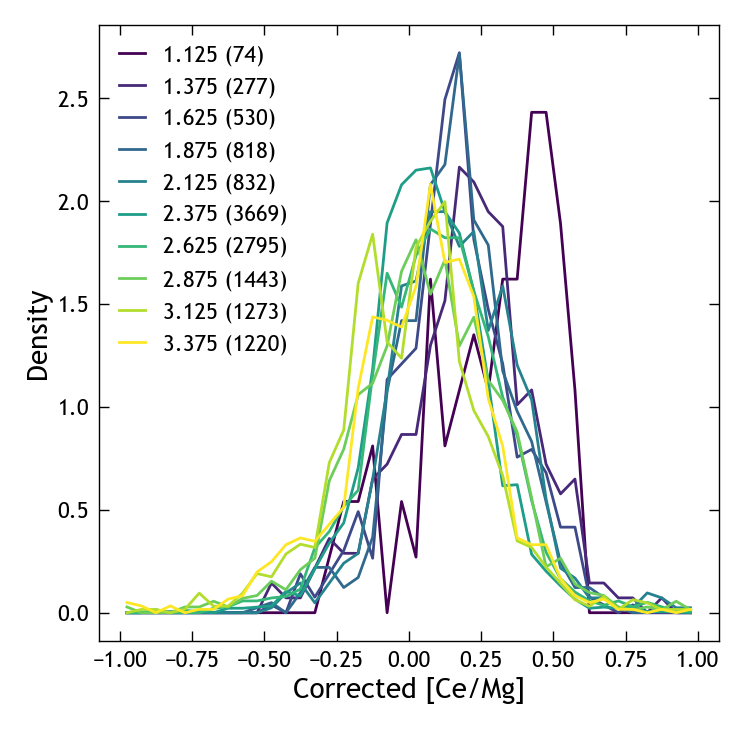

In [176]:
logg_bin_edges = np.arange(1, 3.6, 0.25)
abund_bins = np.arange(-1, 1.02, 0.05)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(logg_bin_edges, radial_cmap.N)
local_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
fig, ax = plt.subplots()
for i in range(len(logg_bin_edges)-1):
    logg_bin = logg_bin_edges[i:i+2]
    mean_logg = np.mean(logg_bin)
    df = local_sample[(local_sample['logg'] > logg_bin[0]) & (local_sample['logg'] < logg_bin[1])]
    hist, bin_edges = np.histogram(df['ce_mg_corr'], bins=abund_bins, density=True)
    # hist_smooth = box_smooth(hist, bin_edges, 0.2)
    ax.plot(get_bin_centers(bin_edges), hist, color=cmap(norm(mean_logg)), label='%s (%s)' % (mean_logg, df.shape[0]))
ax.set_xlabel('Corrected [Ce/Mg]')
ax.set_ylabel('Density')
ax.legend()
plt.show()

Note that for log(g) < 1.5, the metal-rich side of the Kiel diagram gets cut off by the Teff > 4000 K limit. So I wouldn't worry too much about the low-log(g) bins looking weird here. They also have very small sample sizes besides.

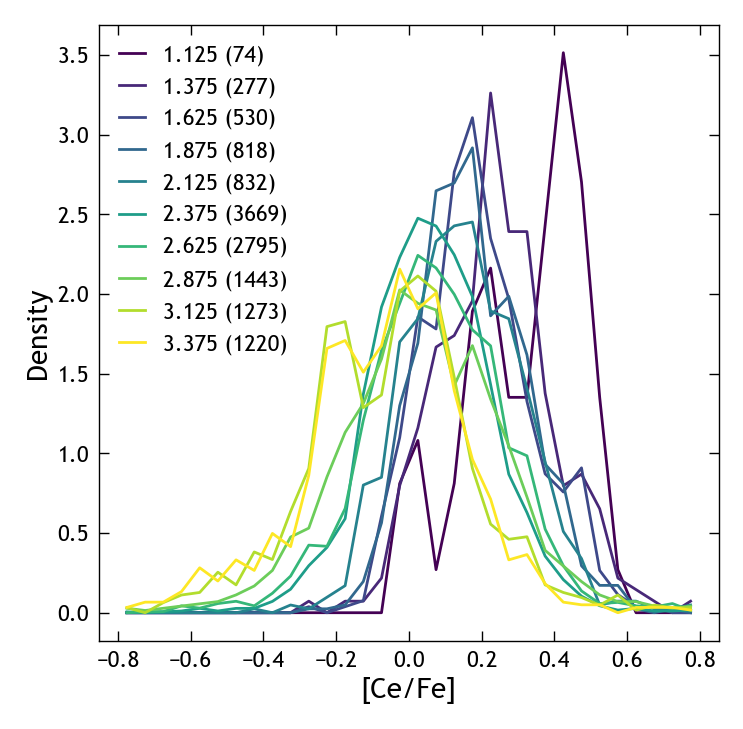

In [123]:
logg_bin_edges = np.arange(1, 3.6, 0.25)
abund_bins = np.arange(-0.8, 0.82, 0.05)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(logg_bin_edges, radial_cmap.N)
local_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
fig, ax = plt.subplots()
for i in range(len(logg_bin_edges)-1):
    logg_bin = logg_bin_edges[i:i+2]
    mean_logg = np.mean(logg_bin)
    df = local_sample[(local_sample['logg'] > logg_bin[0]) & (local_sample['logg'] < logg_bin[1])]
    hist, bin_edges = np.histogram(df['ce_fe'], bins=abund_bins, density=True)
    # hist_smooth = box_smooth(hist, bin_edges, 0.2)
    ax.plot(get_bin_centers(bin_edges), hist, color=cmap(norm(mean_logg)), label='%s (%s)' % (mean_logg, df.shape[0]))
ax.set_xlabel('[Ce/Fe]')
ax.set_ylabel('Density')
ax.legend()
plt.show()

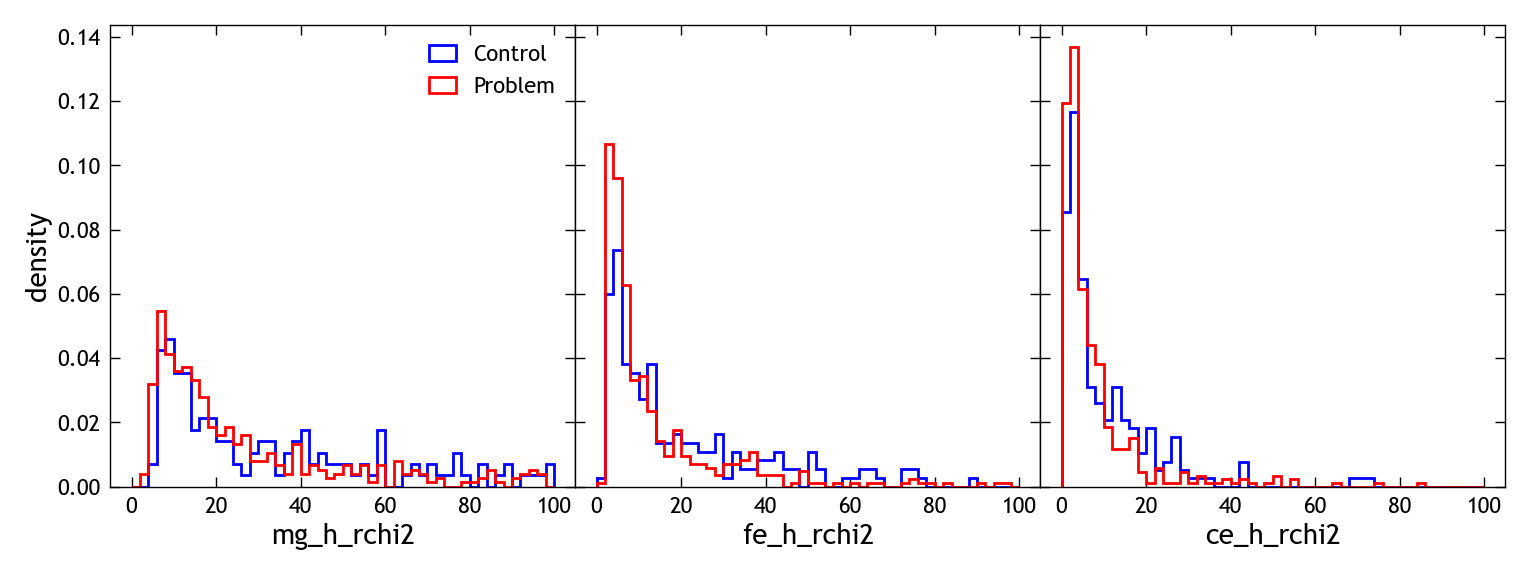

In [188]:
problem = local_sample[
    (local_sample['logg'] > 3) &
    (local_sample['logg'] < 3.5) &
    (local_sample['ce_fe'] > -0.25) &
    (local_sample['ce_fe'] < -0.15)
]
control = local_sample[
    (local_sample['logg'] > 2) &
    (local_sample['logg'] < 2.5) &
    (local_sample['ce_fe'] > -0.25) &
    (local_sample['ce_fe'] < -0.15)
]

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True, gridspec_kw={'wspace': 0})
colors = ['b', 'r']
labels = ['Control', 'Problem']
for i, col in enumerate(['mg_h_rchi2', 'fe_h_rchi2', 'ce_h_rchi2']):
    for j, df in enumerate([control, problem]):
        axs[i].hist(df[col], bins=np.arange(0, 101, 2), density=True, histtype='step', color=colors[j], label=labels[j])
    axs[i].set_xlabel(col)
    # axs[i].set_xlim((0, df[col].quantile(0.995)))
axs[0].set_ylabel('density')
# axs[0].set_xlim((0, 50))
axs[0].legend()
plt.show()

In [125]:
print(full_sample.shape[0])
print(full_sample[full_sample['logg']<3].shape[0])

print(full_sample[full_sample['good_age']].shape[0])
print(full_sample[(full_sample['logg']<3) & (full_sample['good_age'])].shape[0])


120459
107634
104255
94084


## log(g) abundance corrections

Solar neighborhood stars (both on and off the midplane) seem to benefit from the log(g) corrections. On the other hand, luminous giants in the inner and outer galaxy actually look slightly worse with the corrections than without.

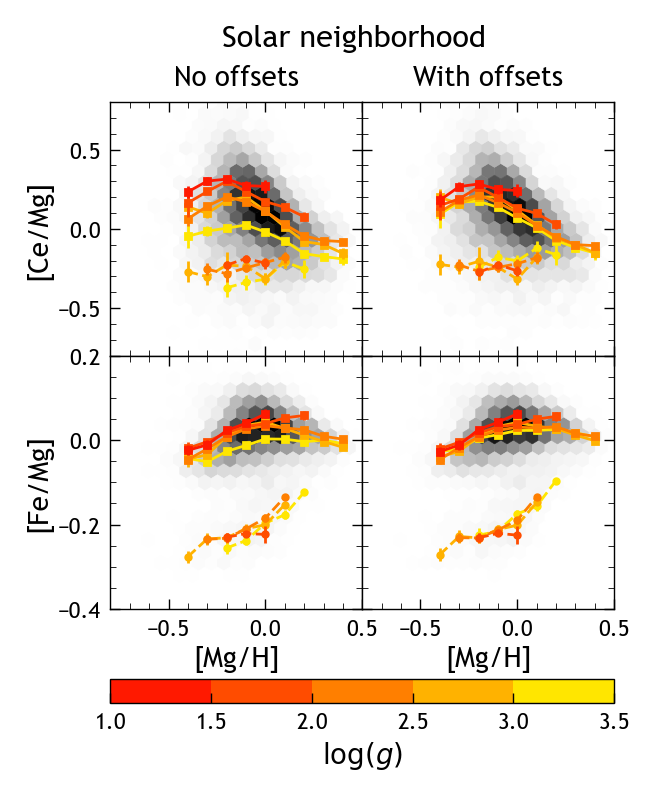

In [126]:
# Initialize grid of log(g), [Mg/H] values
MgH_bin_edges = np.round(np.linspace(-0.75, 0.45, 13, endpoint=True), 2)
MgH_bin_centers = get_bin_centers(MgH_bin_edges)
logg_bin_edges = np.linspace(0, 3.5, 8, endpoint=True)
logg_bin_centers = get_bin_centers(logg_bin_edges)
AXES_LIM = {
    'mg_h': (-0.8, 0.5),
    'ce_mg': (-0.8, 0.8),
    'fe_mg': (-0.4, 0.2)
}

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        local_sample['mg_h'], local_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = local_sample[
            (local_sample['logg'] > logg_lim[0]) & 
            (local_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('Solar neighborhood')
plt.show()

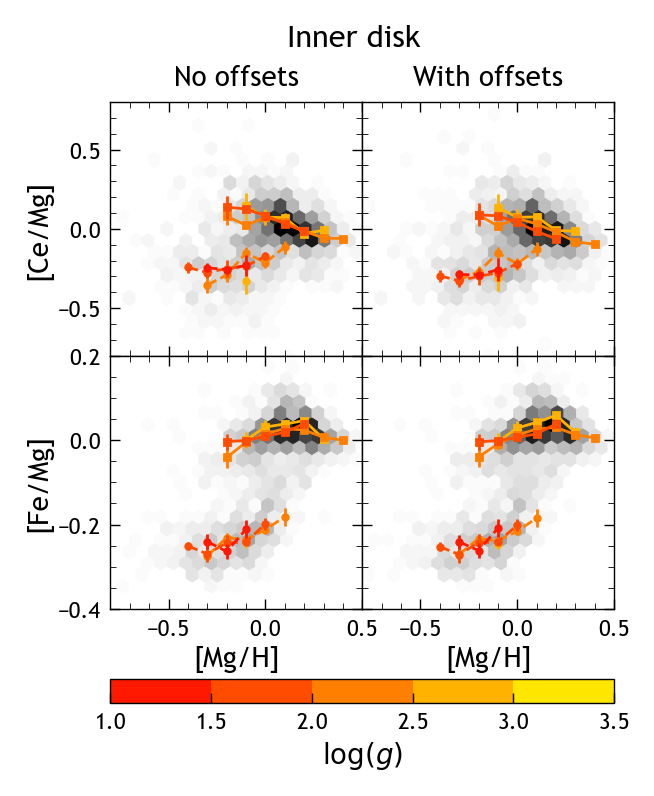

In [127]:
inner_sample = full_sample[(full_sample['Rg'] >= 3) & (full_sample['Rg'] < 5) & (full_sample['z_max'] < 0.5)]

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        inner_sample['mg_h'], inner_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = inner_sample[
            (inner_sample['logg'] > logg_lim[0]) & 
            (inner_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('Inner disk')
plt.show()

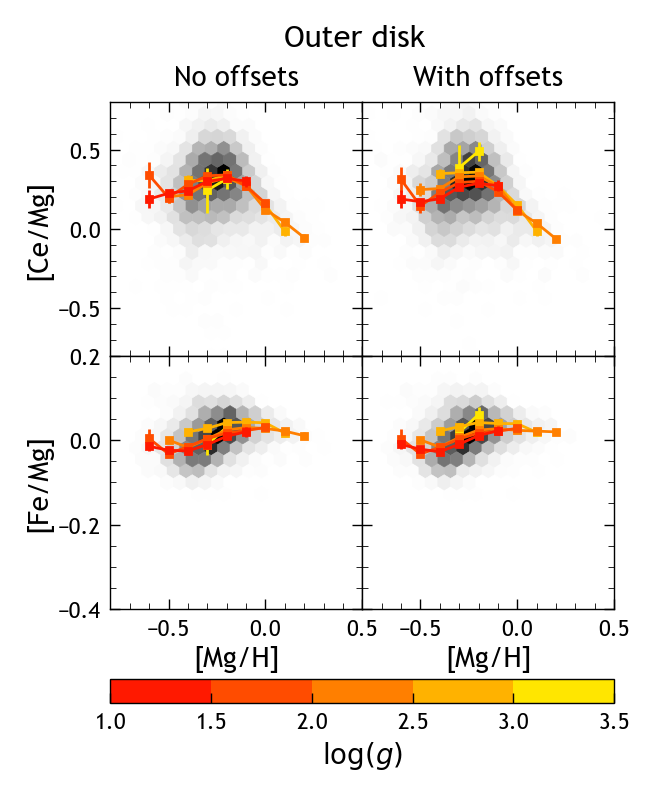

In [128]:
outer_sample = full_sample[(full_sample['Rg'] >= 11) & (full_sample['Rg'] < 13) & (full_sample['z_max'] < 0.5)]

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        outer_sample['mg_h'], outer_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = outer_sample[
            (outer_sample['logg'] > logg_lim[0]) & 
            (outer_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('Outer disk')
plt.show()

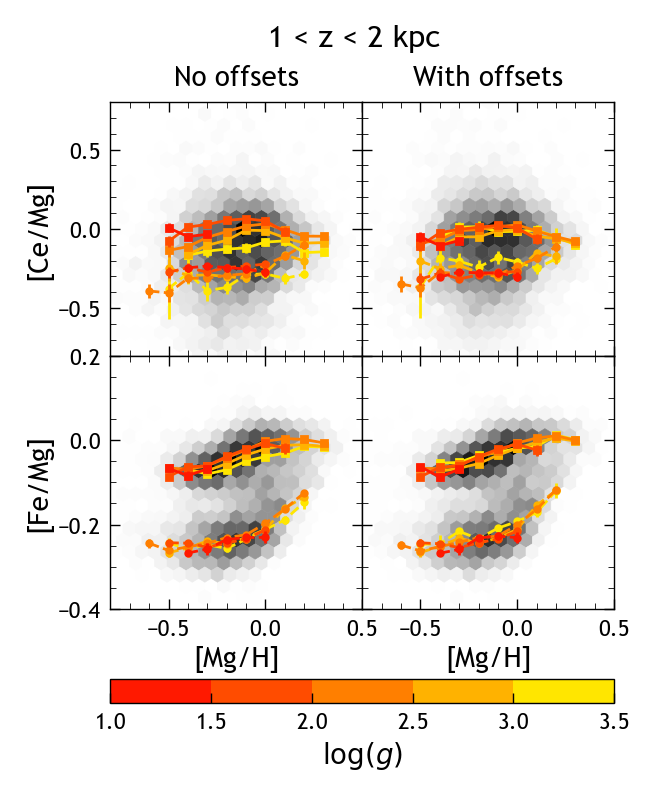

In [129]:
highlat_sample = full_sample[
    (full_sample['Rg'] >= 7) & 
    (full_sample['Rg'] < 9) & 
    (full_sample['z_max'] > 1) &
    (full_sample['z_max'] < 2)
]

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        highlat_sample['mg_h'], highlat_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = highlat_sample[
            (highlat_sample['logg'] > logg_lim[0]) & 
            (highlat_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('1 < z < 2 kpc')
plt.show()

## Limiting distance sources

In [ ]:
full_photogeo = add_kinematics(full_sample.reset_index(), fitspath=paths.data / 'catalogs' / 'sdssv-mwm-dr19-apogee-photogeo-actions.fits', suffix='_photogeo')
full_photogeo.set_index('sdss_id', inplace=True)
full_photogeo

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,Jz_photogeo,Jtot_photogeo,E_photogeo,Lx_photogeo,Ly_photogeo,Lz_photogeo,ecc_photogeo,z_max_photogeo,Rg_photogeo,orbit_flags_photogeo
0,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,1.240400,1987.496249,-125276.554738,0.382520,2.850030,1953.562169,0.154363,0.186984,8.536859,0.0
1,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,0.371947,2086.145136,-123086.161226,-0.503370,-0.140744,2082.844562,0.045397,0.104265,9.141438,0.0
2,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,5.028116,2294.988107,-117869.781363,-0.200598,-0.154839,2263.285095,0.130791,0.465957,10.003855,0.0
3,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,1.033459,2071.965171,-123345.140257,1.048118,3.414492,2060.607675,0.085333,0.177688,9.036594,0.0
4,54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,...,28.562129,3773.946907,-93667.454763,-8.784819,-2.119323,3659.469538,0.182420,2.056165,17.032927,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120454,129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,...,4.700591,2302.176677,-117757.701898,0.378949,-0.439890,2275.684057,0.118067,0.454042,10.063811,0.0
120455,129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,...,5.261480,1905.890932,-127136.632178,1.584429,-0.323053,1854.137929,0.187538,0.411425,8.080668,0.0
120456,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,0.033234,1480.373209,-138331.907122,0.262863,0.533288,1297.591094,0.405834,0.024409,5.690338,0.0
120457,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,2.111943,1991.820284,-125078.671562,10.736140,-2.814496,1952.243274,0.165236,0.250966,8.530756,0.0


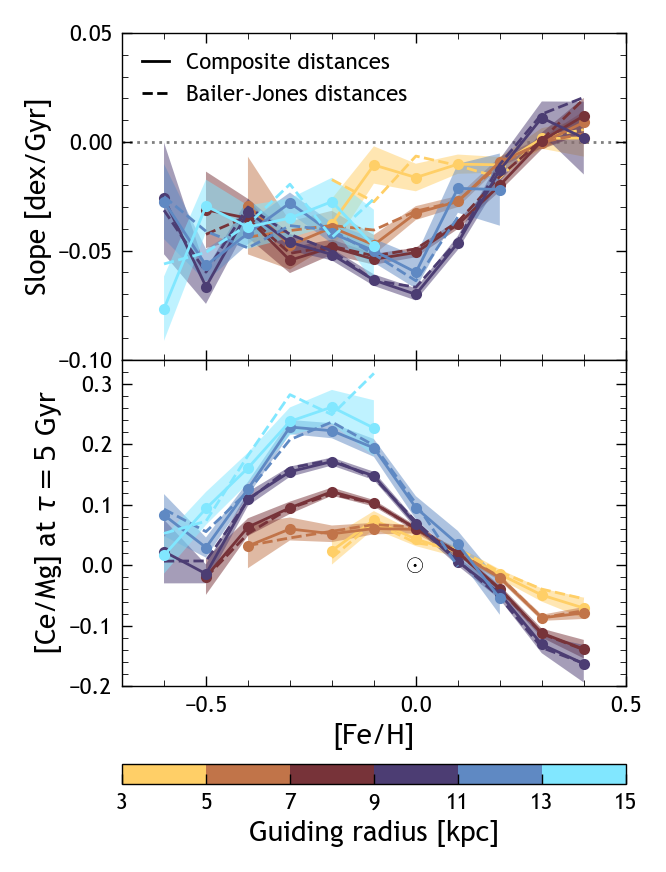

In [198]:
# Metallicity bins
met_bin_edges = np.arange(-0.85, 0.56, 0.1)
dr = 2
radius_bin_edges = np.arange(3, 15+dr, dr)
zlim = (0, 0.5)

# Set up figure
fig, axs = plt.subplots(
    2,
    figsize=(ONE_COLUMN_WIDTH, 1.5*ONE_COLUMN_WIDTH), 
    sharex=True,
    gridspec_kw={'hspace': 0}
)
cmap = plt.get_cmap(RADIUS_COLORMAP)
norm = BoundaryNorm(radius_bin_edges, cmap.N)
cax = insert_colorbar_axes(fig, orientation='horizontal', pad=0.05)

for j in range(len(radius_bin_edges)-1):
    rlim = radius_bin_edges[j:j+2]
    mean_radius = np.mean(rlim)
    color = cmap(norm(mean_radius))
    # First, the fiducial distances
    region = full_photogeo[
        (full_photogeo['Rg'] >= rlim[0]) &
        (full_photogeo['Rg'] < rlim[1]) &
        (full_photogeo['z_max'] >= zlim[0]) &
        (full_photogeo['z_max'] < zlim[1]) &
        (full_photogeo['high_ia']) # restrict age trends to low-alpha only
    ]
    # Bin by metallicity and fit linear trend to stars
    params, errors, mets = fit_metallicity_bins(region, met_bin_edges)
    # Plot fit slopes
    slopes = params[:,1]
    slope_errs = errors[:,1]
    axs[0].plot(
        mets, slopes, '.-',
        color=color,
        label=f'{int(mean_radius)} kpc'
    )
    axs[0].fill_between(
        mets, slopes - slope_errs, slopes + slope_errs,
        color=color, 
        alpha=0.5, 
        edgecolor='none'
    )
    # Plot intercepts
    intercepts = params[:,0]
    int_errs = errors[:,0]
    axs[1].plot(mets, intercepts, '.-', color=color)
    axs[1].fill_between(
        mets, intercepts - int_errs, intercepts + int_errs,
        color=color,
        alpha=0.5,
        edgecolor='none'
    )
    # Next, the Bailer-Jones distances
    region = full_photogeo[
        (full_photogeo['Rg_photogeo'] >= rlim[0]) &
        (full_photogeo['Rg_photogeo'] < rlim[1]) &
        (full_photogeo['z_max_photogeo'] >= zlim[0]) &
        (full_photogeo['z_max_photogeo'] < zlim[1]) &
        (full_photogeo['high_ia']) # restrict age trends to low-alpha only
    ]
    # Bin by metallicity and fit linear trend to stars
    params, errors, mets = fit_metallicity_bins(region, met_bin_edges)
    # Plot fit slopes
    slopes = params[:,1]
    slope_errs = errors[:,1]
    axs[0].plot(
        mets, slopes, '--',
        color=color,
        label=f'{int(mean_radius)} kpc'
    )
    # axs[0].fill_between(
    #     mets, slopes - slope_errs, slopes + slope_errs,
    #     color=color, 
    #     alpha=0.5, 
    #     edgecolor='none'
    # )
    # Plot intercepts
    intercepts = params[:,0]
    int_errs = errors[:,0]
    axs[1].plot(mets, intercepts, '--', color=color)
    # axs[1].fill_between(
    #     mets, intercepts - int_errs, intercepts + int_errs,
    #     color=color,
    #     alpha=0.5,
    #     edgecolor='none'
    # )
# Dotted horizontal line at 0
axs[0].axhline(0, ls=':', c='gray', zorder=0)
# indicate Solar value
axs[1].plot(0, 0, 'wo', zorder=9)
axs[1].text(
    0, 0, r'$\odot$',
    va='center', ha='center', zorder=10, weight='bold', usetex=True
)

# Colorbar
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    orientation='horizontal', 
    label='Guiding radius [kpc]'
)

# Legend
lines = [
    Line2D([0], [0], color='k', linestyle='-'),
    Line2D([0], [0], color='k', linestyle='--'),
]
labels = ['Composite distances', 'Bailer-Jones distances']
axs[0].legend(lines, labels)

# Format axes
axs[0].set_xlim((-0.7, 0.5))
axs[0].set_ylim((-0.1, 0.05))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.05))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.01))
axs[0].set_ylabel('Slope [dex/Gyr]')
axs[1].set_ylim((-0.2, 0.34))
axs[1].yaxis.set_major_locator(MultipleLocator(0.1))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.02))
axs[1].set_ylabel(r'[Ce/Mg] at $\tau=5$ Gyr')
axs[1].set_xlabel('[Fe/H]')
plt.savefig(paths.extra / 'global_metallicity_fits_distance_test')
plt.show()

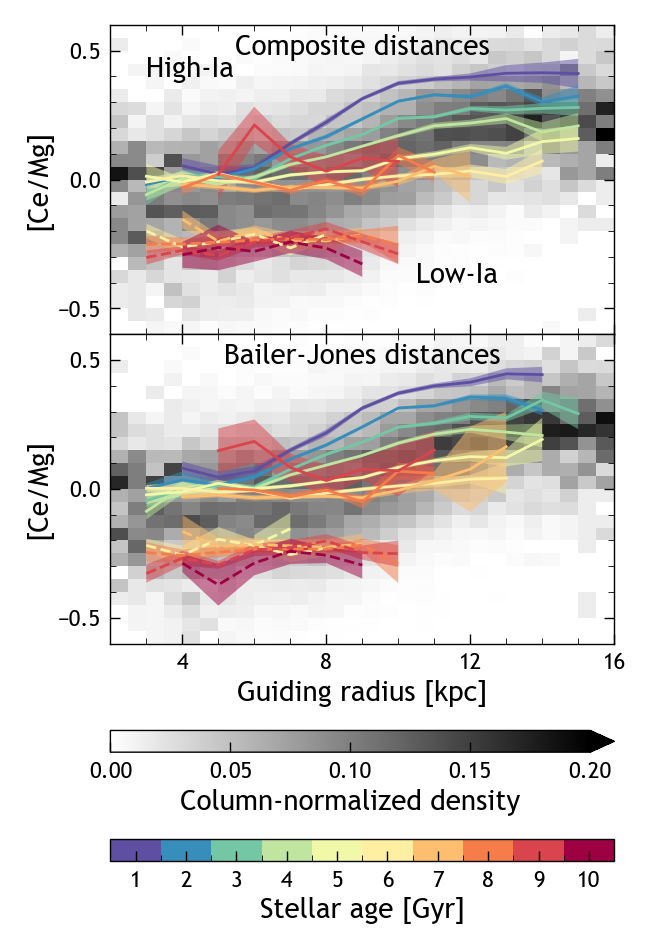

In [195]:
radius_bin_edges = np.arange(2.5, 15.6, 1)
age_bin_edges = np.arange(0.5, 10.6, 1)
fine_Rg_bins = np.arange(0, 16.1, 0.5)
fine_ce_bins = np.arange(-0.8, 0.81, 0.05)

# Select only low-alpha, near-midplane stars
all_lowz = full_photogeo[(full_photogeo['z_max'] < 0.5) & (full_photogeo['good_age'])].copy()
all_high_ia = all_lowz[(all_lowz['high_ia'])].copy()
all_low_ia = all_lowz[(all_lowz['low_ia'])].copy()

# Set up figure
fig, axs = plt.subplots(
    2, 1,
    figsize=(ONE_COLUMN_WIDTH, 1.67*ONE_COLUMN_WIDTH),
    sharex=True,
    gridspec_kw={'hspace': 0.}
)
# fig.subplots_adjust(left=0.1, right=0.95)
age_cmap = plt.get_cmap(AGE_COLORMAP)
age_norm = BoundaryNorm(age_bin_edges, age_cmap.N)
age_cax = insert_colorbar_axes(fig, 'horizontal', pad=0.05)
density_cmap = 'binary'
density_norm = Normalize(vmin=0, vmax=0.2)
density_cax = insert_colorbar_axes(fig, 'horizontal', pad=0.05)
xlim = (2, 16)
ylim = [(-0.6, 0.6), (-0.6, 0.6)]

for i, col in enumerate(['Rg', 'Rg_photogeo']):
    H, xedges, yedges = np.histogram2d(
        all_lowz[col], all_lowz['ce_mg_corr'],
        bins=[fine_Rg_bins, fine_ce_bins],
        density=True
    )
    # normalize by column
    H_norm_cols = H / np.sum(H, axis=0, keepdims=True)
    pcm = axs[i].pcolormesh(
        xedges, yedges, H_norm_cols,
        cmap=density_cmap,
        norm=density_norm
    )
    # fig.colorbar(pcm, ax=axs[i])

    for j in range(len(age_bin_edges)-1):
        age_bin = age_bin_edges[j:j+2]
        mean_age = np.mean(age_bin)
        color = age_cmap(age_norm(mean_age))
        # Plot high-alpha trends
        low_ia_subset = all_low_ia[
            (all_low_ia['age'] >= age_bin[0]) &
            (all_low_ia['age'] < age_bin[1])
        ]
        low_ia_medians = binned_quantiles(
            low_ia_subset, 'ce_mg_corr', col,
            q=0.5, bin_edges=radius_bin_edges, min_count=10, est_errors=True
        )
        # axs[i].plot(*low_ia_medians, '-', color='w', linewidth=2)
        # axs[i].plot(
        #     *low_ia_medians, '--', 
        #     color=age_cmap(norm(mean_age)), 
        # )
        axs[i].plot(
            *low_ia_medians[:-1], '--', 
            color=color, zorder=3
        )
        axs[i].fill_between(
            low_ia_medians[0],
            low_ia_medians[1]+low_ia_medians[2],
            low_ia_medians[1]-low_ia_medians[2],
            color=color,
            edgecolor='none', alpha=0.5, zorder=1
        )
        # Plot low-alpha trends
        high_ia_subset = all_high_ia[
            (all_high_ia['age'] >= age_bin[0]) &
            (all_high_ia['age'] < age_bin[1])
        ]
        high_ia_medians = binned_quantiles(
            high_ia_subset, 'ce_mg_corr', col,
            q=0.5, bin_edges=radius_bin_edges, min_count=10, est_errors=True
        )
        # axs[i].plot(*high_ia_medians, '-', color='w', linewidth=2)
        # axs[i].plot(
        #     *high_ia_medians, '-', 
        #     color=age_cmap(norm(mean_age)), 
        #     label=f'{int(mean_age)} Gyr'
        # )
        axs[i].plot(
            *high_ia_medians[:-1], '-', 
            color=color, 
            zorder=4, 
            label=f'{int(mean_age)} Gyr'
        )
        axs[i].fill_between(
            high_ia_medians[0],
            high_ia_medians[1]+high_ia_medians[2],
            high_ia_medians[1]-high_ia_medians[2],
            color=color,
            edgecolor='none', 
            alpha=0.5, 
            zorder=2
        )
# Label low- and high-Ia trends
axs[0].text(3, 0.4, 'High-Ia', fontsize=plt.rcParams['axes.titlesize'])
axs[0].text(10.5, -0.4, 'Low-Ia', fontsize=plt.rcParams['axes.titlesize'])
# Density colorbar
fig.colorbar(
    pcm, 
    cax=density_cax, 
    orientation='horizontal', 
    label='Column-normalized density', 
    extend='max'
)
# Age bin colorbar
fig.colorbar(
    ScalarMappable(cmap=age_cmap, norm=age_norm),
    cax=age_cax,
    orientation='horizontal',
    label='Stellar age [Gyr]'
)
age_cax.xaxis.set_major_locator(MultipleLocator(1))

axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim[0])
axs[1].set_ylim(ylim[1])

axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1].yaxis.set_major_locator(MultipleLocator(0.5))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1].xaxis.set_major_locator(MultipleLocator(4))
axs[1].xaxis.set_minor_locator(MultipleLocator(1))

axs[0].set_ylabel('[Ce/Mg]')
axs[1].set_ylabel('[Ce/Mg]')
axs[1].set_xlabel('Guiding radius [kpc]')

axs[0].set_title('Composite distances', y=0.85)
axs[1].set_title('Bailer-Jones distances', y=0.85)
plt.savefig(paths.extra / 'gradients_distance_test')
plt.show()

In [196]:
full_photogeo = residual_abundances(full_photogeo, rbins=[(3, 5), (5, 7), (7, 9), (9, 11), (11, 13), (13, 15)], zbins=[(0, 0.5)])

ValueError: columns overlap but no suffix specified: Index(['delta_ce_h'], dtype='object')

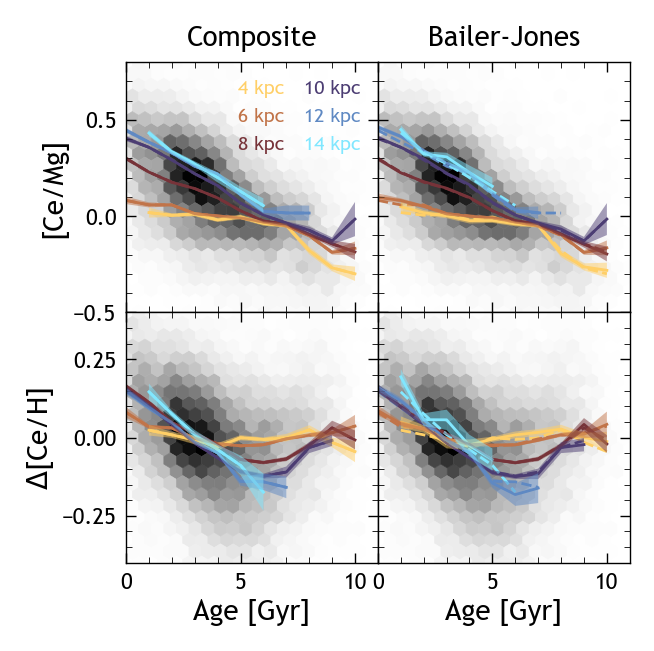

In [197]:
radius_bin_edges = np.arange(3, 15.1, 2)
age_bin_edges = np.arange(-0.5, 11.6, 1)
radial_cmap = plt.get_cmap(RADIUS_COLORMAP)
norm = BoundaryNorm(radius_bin_edges, radial_cmap.N)

fig, axs = plt.subplots(
    2, 2, 
    figsize=(ONE_COLUMN_WIDTH, ONE_COLUMN_WIDTH), 
    sharex=True, sharey='row', 
    gridspec_kw={'wspace': 0, 'hspace': 0}
)
xlim = (0, 11)
ylim = [(-0.5, 0.8), (-0.4, 0.4)]
col_labels = ['Composite', 'Bailer-Jones']
abund_labels = ['[Ce/Mg]', r'$\Delta$[Ce/H]']
lowz_ages = full_photogeo[
    (full_photogeo['z_max'] <= 0.5) &
    (full_photogeo['good_age'])
]
for k, abund in enumerate(['ce_mg_corr', 'delta_ce_h']):
    for i, col in enumerate(['Rg', 'Rg_photogeo']):
        # Plot all stars
        pcm = axs[k,i].hexbin(
            lowz_ages['age'], lowz_ages[abund],
            C=np.ones(lowz_ages.shape[0]),
            reduce_C_function=np.sum,
            gridsize=20,
            cmap='binary',
            linewidths=0.2,
            mincnt=0,
            extent=[xlim[0], xlim[1], ylim[k][0], ylim[k][1]]
        )
        # Plot median age trends binned by radius
        for j in range(len(radius_bin_edges)-1):
            radius_bin = radius_bin_edges[j:j+2]
            mean_radius = np.mean(radius_bin)
            subset = lowz_ages[
                (lowz_ages[col] >= radius_bin[0]) &
                (lowz_ages[col] < radius_bin[1])
            ]
            age_medians = binned_quantiles(
                subset, abund, 'age',
                q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
            )
            axs[k,i].plot(
                *age_medians[:-1], '-', 
                color=radial_cmap(norm(mean_radius)), zorder=1,
                label=f'{int(mean_radius)} kpc'
            )
            axs[k,i].fill_between(
                age_medians[0],
                age_medians[1]+age_medians[2],
                age_medians[1]-age_medians[2],
                color=radial_cmap(norm(mean_radius)),
                alpha=0.5, edgecolor='none', zorder=2
            )
            # Compare vs median trends in full sample
            full_subset = lowz_ages[
                (lowz_ages['Rg'] >= radius_bin[0]) &
                (lowz_ages['Rg'] < radius_bin[1])
            ]
            full_age_medians = binned_quantiles(
                full_subset, abund, 'age',
                q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
            )
            axs[k,i].plot(
                *full_age_medians[:-1], '--', 
                color=radial_cmap(norm(mean_radius)), zorder=1,
            )
        # Sample size
        # axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
for i, label in enumerate(col_labels):
    axs[0,i].set_title(label)
for i, label in enumerate(abund_labels):
    axs[i,0].set_ylabel(label)
    axs[i,0].set_ylim(ylim[i])
for ax in axs[-1]:
    ax.set_xlabel('Age [Gyr]')
axs[0,0].set_xlim(xlim)
axs[0,0].xaxis.set_major_locator(MultipleLocator(5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.25))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
colored_text_legend(axs[0,0], ncols=2, fontsize=7, columnspacing=1)
plt.savefig(paths.extra / 'residual_age_trends_distance_test')
plt.show()